# Dự án Machine Learning: Titanic — Dự đoán khả năng sống sót

**Bài toán:** Phân loại nhị phân (Binary Classification) — dự đoán một hành khách trên tàu Titanic có sống sót hay không, dựa trên các thông tin như giới tính, hạng vé, tuổi, số người thân đi cùng...

**Cách trình bày:** Notebook này áp dụng **quy trình 6 bước** cho một dự án Machine Learning được trình bày ở **Phần III — Projects**, sách *Machine Learning Mastery With Python* (Jason Brownlee), cụ thể là mẫu ở Chương 18 (*Predictive Modeling Project Template*), phỏng theo cấu trúc case study phân loại nhị phân ở Chương 21:

1. **Prepare Problem** — Chuẩn bị bài toán (load thư viện, load dữ liệu)
2. **Summarize Data** — Tóm tắt dữ liệu (thống kê mô tả, trực quan hóa)
3. **Prepare Data** — Chuẩn bị dữ liệu (làm sạch, chọn/tạo đặc trưng, biến đổi dữ liệu)
4. **Evaluate Algorithms** — Đánh giá thuật toán (tách tập validation, spot-check nhiều mô hình, so sánh)
5. **Improve Accuracy** — Cải thiện độ chính xác (tuning tham số, ensemble)
6. **Finalize Model** — Hoàn thiện mô hình (dự đoán, lưu mô hình, tạo file submission)

**Dữ liệu:** `train.csv`, `test.csv`, `gender_submission.csv` (bộ dữ liệu Titanic kinh điển trên Kaggle).


## 1. Prepare Problem

### 1.a) Load libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

RANDOM_STATE = 7

### 1.b) Load dataset

In [4]:
train_df = pd.read_csv('C:\\Users\\MSI GAMING\\Documents\\Tài liệu môn học\\Học sâu\\Week 2 - Quy trình học sâu\\Làm quen với quy trình máy học\\Titanic\\train.csv')
test_df = pd.read_csv('C:\\Users\\MSI GAMING\\Documents\\Tài liệu môn học\\Học sâu\\Week 2 - Quy trình học sâu\\Làm quen với quy trình máy học\\Titanic\\test.csv')

print('Kích thước tập train:', train_df.shape)
print('Kích thước tập test :', test_df.shape)
train_df.head()

Kích thước tập train: (891, 12)
Kích thước tập test : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Summarize Data

### 2.a) Descriptive statistics

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [7]:
train_df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [8]:
# Phân bố lớp (Class Distribution) — biến mục tiêu Survived
print(train_df['Survived'].value_counts())
print(train_df['Survived'].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [9]:
# Ma trận tương quan giữa các biến số
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
train_df[numeric_cols].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### 2.b) Data visualizations

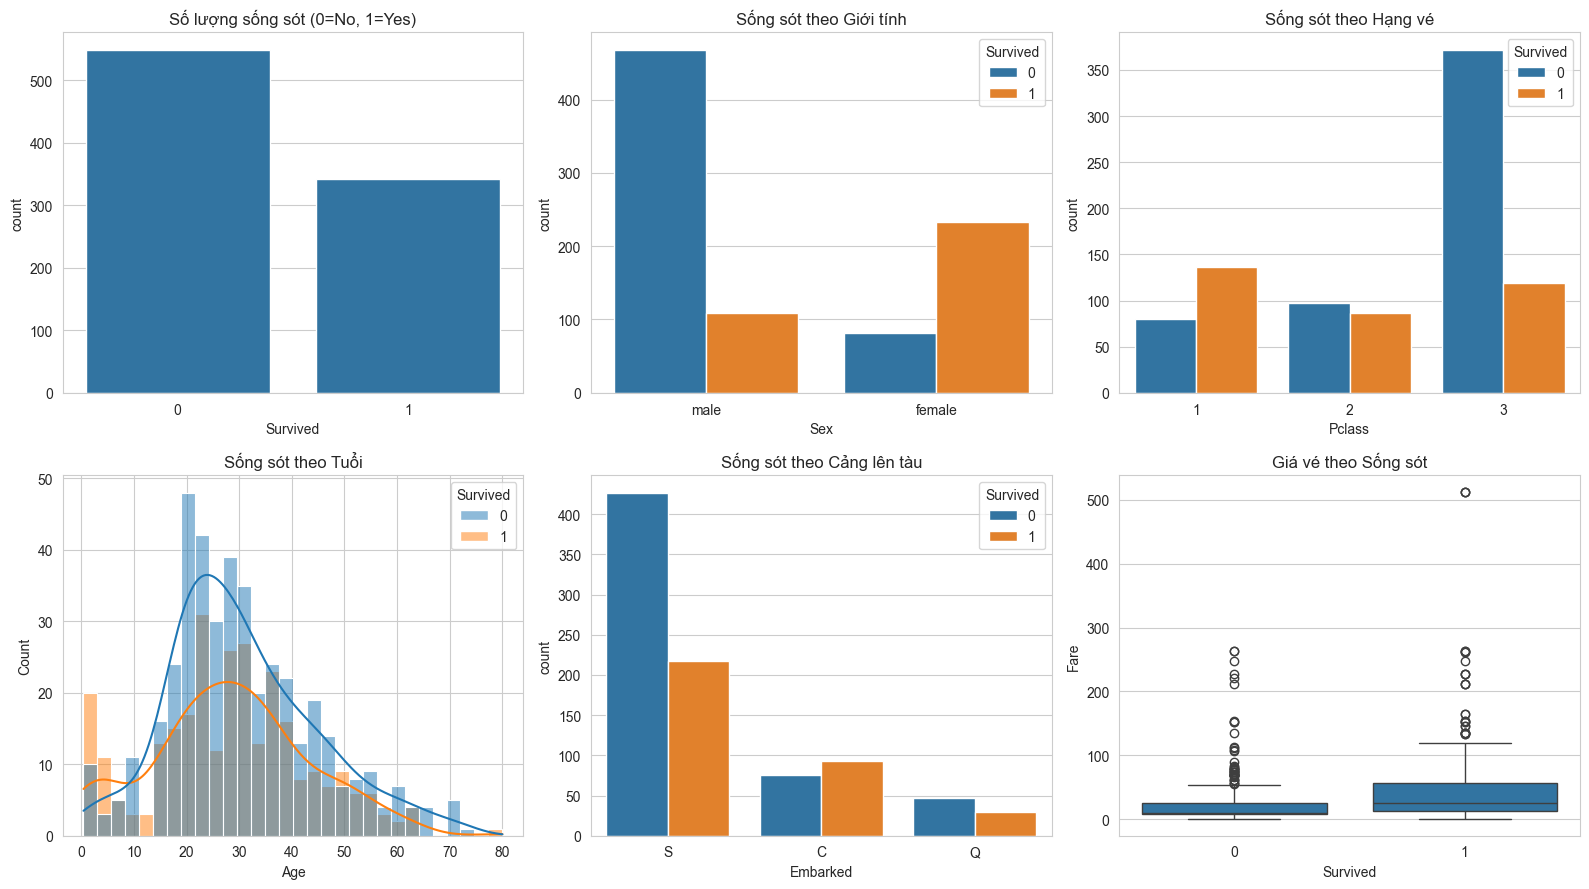

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=train_df, x='Survived', ax=axes[0, 0]).set_title('Số lượng sống sót (0=No, 1=Yes)')
sns.countplot(data=train_df, x='Sex', hue='Survived', ax=axes[0, 1]).set_title('Sống sót theo Giới tính')
sns.countplot(data=train_df, x='Pclass', hue='Survived', ax=axes[0, 2]).set_title('Sống sót theo Hạng vé')
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[1, 0]).set_title('Sống sót theo Tuổi')
sns.countplot(data=train_df, x='Embarked', hue='Survived', ax=axes[1, 1]).set_title('Sống sót theo Cảng lên tàu')
sns.boxplot(data=train_df, x='Survived', y='Fare', ax=axes[1, 2]).set_title('Giá vé theo Sống sót')

plt.tight_layout()
plt.show()

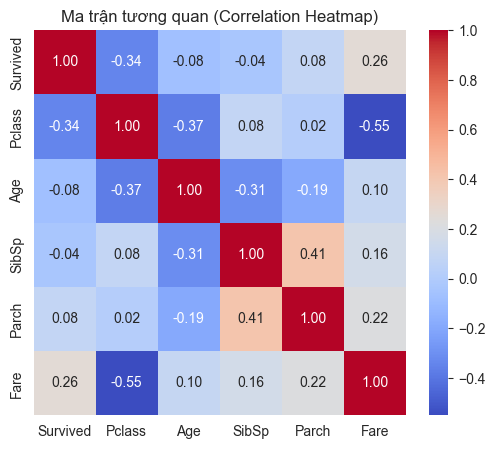

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan (Correlation Heatmap)')
plt.show()

## 3. Prepare Data

Kết hợp tạm thời `train` và `test` để xử lý làm sạch/đặc trưng nhất quán, sau đó tách lại.

### 3.a) Data Cleaning

In [12]:
train_len = len(train_df)
full_df = pd.concat([train_df.drop(columns=['Survived']), test_df], axis=0, ignore_index=True)

# Điền Age bị thiếu bằng median theo nhóm (Pclass, Sex)
full_df['Age'] = full_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Điền Embarked bị thiếu bằng giá trị phổ biến nhất (mode)
full_df['Embarked'] = full_df['Embarked'].fillna(full_df['Embarked'].mode()[0])

# Điền Fare bị thiếu (nếu có, thường ở tập test) bằng median theo Pclass
full_df['Fare'] = full_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

print('Số lượng missing sau khi làm sạch:')
print(full_df[['Age', 'Embarked', 'Fare']].isnull().sum())

Số lượng missing sau khi làm sạch:
Age         0
Embarked    0
Fare        0
dtype: int64


### 3.b) Feature Engineering & Feature Selection

In [13]:
# Trích xuất Title (chức danh) từ cột Name — thường là đặc trưng rất mạnh cho Titanic
full_df['Title'] = full_df['Name'].str.extract(r',\s*([^\.]*)\.')
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
full_df['Title'] = full_df['Title'].replace(title_map)
full_df.loc[~full_df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Rare']), 'Title'] = 'Rare'

# Kích thước gia đình đi cùng và cờ đi một mình
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1
full_df['IsAlone'] = (full_df['FamilySize'] == 1).astype(int)

# Có thông tin Cabin hay không (thay vì dùng trực tiếp Cabin — quá nhiều missing)
full_df['HasCabin'] = full_df['Cabin'].notnull().astype(int)

# Mã hóa biến phân loại
full_df['Sex'] = full_df['Sex'].map({'male': 0, 'female': 1})
full_df = pd.get_dummies(full_df, columns=['Embarked', 'Title'], drop_first=True)

# Loại bỏ các cột không dùng cho mô hình
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
model_df = full_df.drop(columns=drop_cols)

# Đảm bảo toàn bộ cột là số
model_df = model_df.astype(float)

print('Các đặc trưng dùng để huấn luyện:')
print(list(model_df.columns))
model_df.head()

Các đặc trưng dùng để huấn luyện:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3.0,0.0,22.0,1.0,0.0,7.2500,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,1.0,38.0,1.0,0.0,71.2833,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3.0,1.0,26.0,0.0,0.0,7.9250,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,1.0,1.0,35.0,1.0,0.0,53.1000,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,3.0,0.0,35.0,0.0,0.0,8.0500,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### 3.c) Data Transforms — tách lại train/test và chuẩn hóa

In [14]:
X = model_df.iloc[:train_len, :].values
y = train_df['Survived'].values
X_kaggle_test = model_df.iloc[train_len:, :].values

# Tách tập validation (giữ lại để đánh giá cuối cùng, giống 'Validation Dataset' trong sách)
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_validation_scaled = scaler.transform(X_validation)

print('X_train:', X_train.shape, ' X_validation:', X_validation.shape)

X_train: (712, 15)  X_validation: (179, 15)


## 4. Evaluate Algorithms

### 4.a) Split-out validation dataset
Đã thực hiện ở bước 3.c (tỉ lệ 80/20, phân tầng theo `Survived`).

### 4.b) Test options and evaluation metric
Dùng **Stratified 10-fold Cross Validation** trên tập train, độ đo **Accuracy** — phù hợp vì bài toán phân loại và lớp không quá mất cân bằng (~62% / 38%).

In [15]:
seed = RANDOM_STATE
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

models = []
models.append(('LR', LogisticRegression(max_iter=1000)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('RF', RandomForestClassifier(random_state=seed)))

results = []
names = []
print(f"{'Model':6s}  {'Mean Accuracy':>13s}  {'Std':>8s}")
for name, model in models:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name:6s}  {cv_results.mean():13.4f}  {cv_results.std():8.4f}')

Model   Mean Accuracy       Std
LR             0.8216    0.0259
KNN            0.8203    0.0245
CART           0.7795    0.0460
NB             0.7949    0.0343
SVM            0.8258    0.0297
RF             0.8131    0.0305


### 4.d) Compare Algorithms

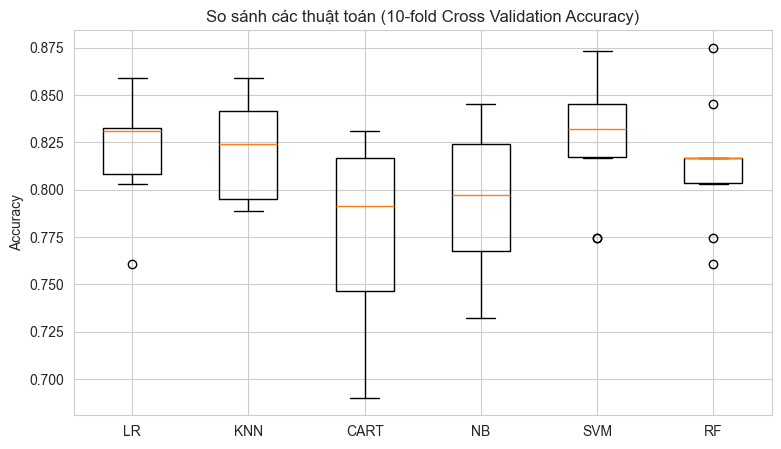

In [16]:
plt.figure(figsize=(9, 5))
plt.boxplot(results, labels=names)
plt.title('So sánh các thuật toán (10-fold Cross Validation Accuracy)')
plt.ylabel('Accuracy')
plt.show()

## 5. Improve Accuracy

### 5.a) Algorithm Tuning
Chọn **Random Forest** và **SVM** (thường trong nhóm tốt nhất ở bước spot-check) để tinh chỉnh siêu tham số bằng Grid Search.

In [17]:
param_grid_rf = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=seed), param_grid_rf, cv=kfold, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
print('RF - Best score :', grid_rf.best_score_)
print('RF - Best params:', grid_rf.best_params_)

RF - Best score : 0.8300273865414711
RF - Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}


In [18]:
param_grid_svm = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}
grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=kfold, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)
print('SVM - Best score :', grid_svm.best_score_)
print('SVM - Best params:', grid_svm.best_params_)

SVM - Best score : 0.8314553990610328
SVM - Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


### 5.b) Ensembles
So sánh thêm các phương pháp ensemble (Bagging/Boosting) và tạo một **Voting Classifier** kết hợp các mô hình đã tinh chỉnh.

In [19]:
ensembles = []
ensembles.append(('AB', AdaBoostClassifier(random_state=seed)))
ensembles.append(('GBM', GradientBoostingClassifier(random_state=seed)))
ensembles.append(('RF-tuned', grid_rf.best_estimator_))
ensembles.append(('SVM-tuned', grid_svm.best_estimator_))

ens_results = []
ens_names = []
for name, model in ensembles:
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    ens_results.append(cv_results)
    ens_names.append(name)
    print(f'{name:10s}  {cv_results.mean():.4f}  ({cv_results.std():.4f})')

voting_clf = VotingClassifier(estimators=[
    ('rf', grid_rf.best_estimator_),
    ('svm', grid_svm.best_estimator_),
    ('gbm', GradientBoostingClassifier(random_state=seed))
], voting='soft')

voting_cv = cross_val_score(voting_clf, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
print(f'{"Voting":10s}  {voting_cv.mean():.4f}  ({voting_cv.std():.4f})')

AB          0.8104  (0.0339)
GBM         0.8089  (0.0359)
RF-tuned    0.8300  (0.0263)
SVM-tuned   0.8315  (0.0244)
Voting      0.8245  (0.0208)


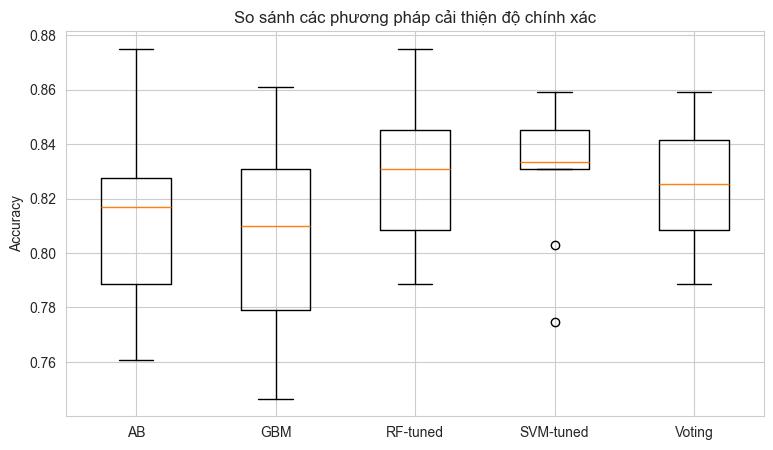

In [20]:
plt.figure(figsize=(9, 5))
all_results = ens_results + [voting_cv]
all_names = ens_names + ['Voting']
plt.boxplot(all_results, labels=all_names)
plt.title('So sánh các phương pháp cải thiện độ chính xác')
plt.ylabel('Accuracy')
plt.show()

## 6. Finalize Model

### 6.a) Predictions on validation dataset
Chọn mô hình tốt nhất theo cross-validation (giữa RF-tuned, SVM-tuned, Voting) và đánh giá trên tập validation (dữ liệu chưa từng thấy trong quá trình huấn luyện/tuning).

In [21]:
candidates = {
    'RF-tuned': grid_rf.best_estimator_,
    'SVM-tuned': grid_svm.best_estimator_,
    'Voting': voting_clf
}

best_name, best_score = None, -1
for name, model in candidates.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_validation_scaled)
    acc = accuracy_score(y_validation, preds)
    print(f'{name:10s} - Validation Accuracy: {acc:.4f}')
    if acc > best_score:
        best_name, best_score, best_preds = name, acc, preds

print(f'\n=> Mô hình được chọn: {best_name} (Validation Accuracy = {best_score:.4f})')
print('\nClassification report:')
print(classification_report(y_validation, best_preds))

RF-tuned   - Validation Accuracy: 0.8212
SVM-tuned  - Validation Accuracy: 0.8324
Voting     - Validation Accuracy: 0.8268

=> Mô hình được chọn: SVM-tuned (Validation Accuracy = 0.8324)

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



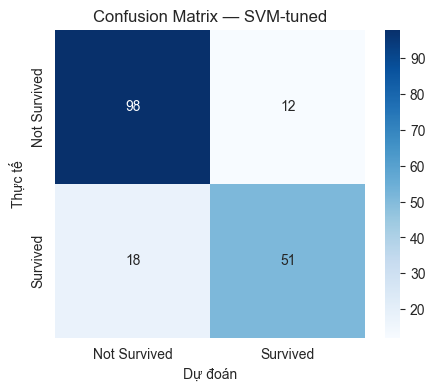

In [22]:
cm = confusion_matrix(y_validation, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

### 6.b) Create standalone model on entire training dataset

In [23]:
final_model = candidates[best_name]

X_full_scaled = StandardScaler().fit(X).transform(X)  # scaler khớp trên toàn bộ train
final_scaler = StandardScaler().fit(X)
X_full_scaled = final_scaler.transform(X)

final_model.fit(X_full_scaled, y)
print('Đã huấn luyện lại mô hình cuối cùng trên toàn bộ dữ liệu train.')

Đã huấn luyện lại mô hình cuối cùng trên toàn bộ dữ liệu train.


### 6.c) Save model for later use

In [24]:
with open('titanic_final_model.pkl', 'wb') as f:
    pickle.dump({'model': final_model, 'scaler': final_scaler, 'columns': list(model_df.columns)}, f)
print('Đã lưu mô hình vào titanic_final_model.pkl')

Đã lưu mô hình vào titanic_final_model.pkl


### 6.d) Dự đoán trên tập test của Kaggle và tạo file submission

In [25]:
X_kaggle_scaled = final_scaler.transform(X_kaggle_test)
kaggle_preds = final_model.predict(X_kaggle_scaled).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': kaggle_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## Tổng kết

- Đã đi qua đầy đủ **6 bước** của quy trình dự án ML theo sách *Machine Learning Mastery With Python* (Chương 18–21, Phần III — Projects).
- Bài toán Titanic là một **bài toán phân loại nhị phân**: các bước tương tự case study ở Chương 21 của sách (Pima Indians Diabetes).
- Mô hình tốt nhất được chọn dựa trên **Accuracy trên tập validation** (dữ liệu hoàn toàn tách biệt khỏi quá trình huấn luyện/tuning), sau đó huấn luyện lại trên **toàn bộ** dữ liệu train trước khi dự đoán trên tập test thật (Kaggle) — đúng tinh thần "Finalize Model" mà sách khuyến nghị.
- File `submission.csv` là kết quả dự đoán sẵn sàng nộp lên Kaggle; `titanic_final_model.pkl` là mô hình đã lưu để tái sử dụng sau này.
